<a href="https://colab.research.google.com/github/sidroch/Olist-Ecommerce-Analysis/blob/main/TC_Fase2_WineQualit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importações das Bibliotecas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# Carregar os dados do arquivo CSV

In [ ]:
# Importando o CSV com passagem de parâmetros
from google.colab import files
uploaded = files.upload()

# Nome do arquivo enviado
df = pd.read_csv(list(uploaded.keys())[0])

df.head(10000)


# Criação de variável alvo binária

In [ ]:
df['quality_bin'] = (df['quality'] >= 7).astype(int)
df[['quality', 'quality_bin']].head()


,quality,quality_bin
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


# Estatísticas iniciais

In [ ]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_bin           1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB
None
       fixed acidit

# Realocando os itens de qualidades

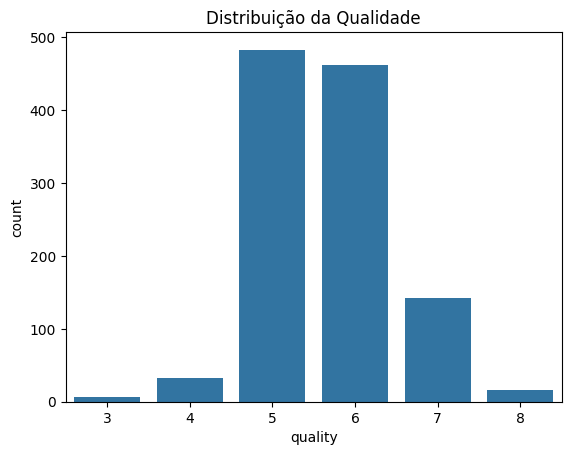

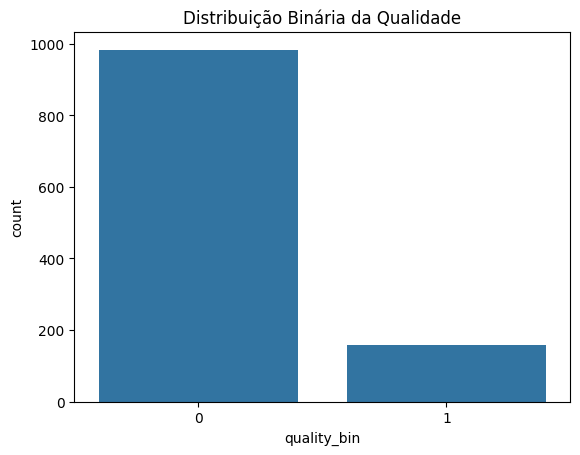

In [ ]:
sns.countplot(data=df, x='quality')
plt.title('Distribuição da Qualidade')
plt.show()

sns.countplot(data=df, x='quality_bin')
plt.title('Distribuição Binária da Qualidade')
plt.show()


# Matriz de corelação

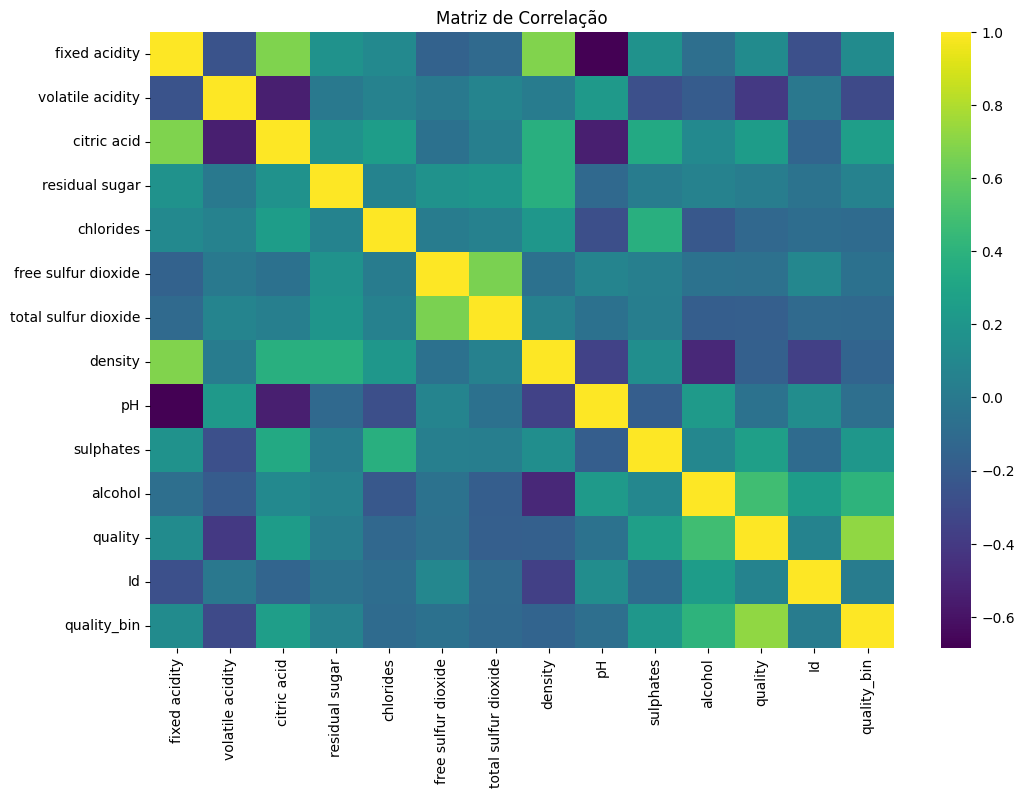

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='viridis')
plt.title('Matriz de Correlação')
plt.show()


# Boxplots comparando vinhos bons vs ruins

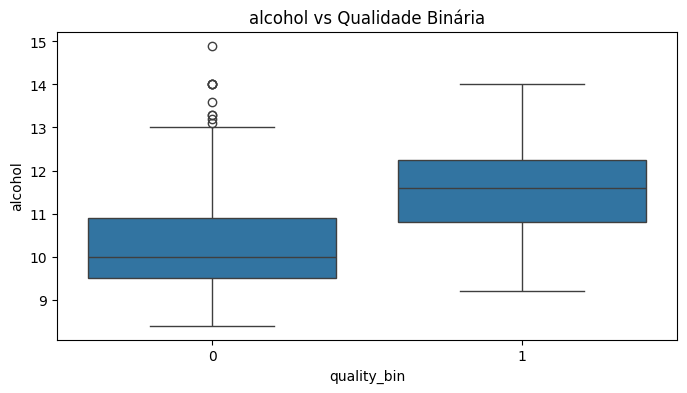

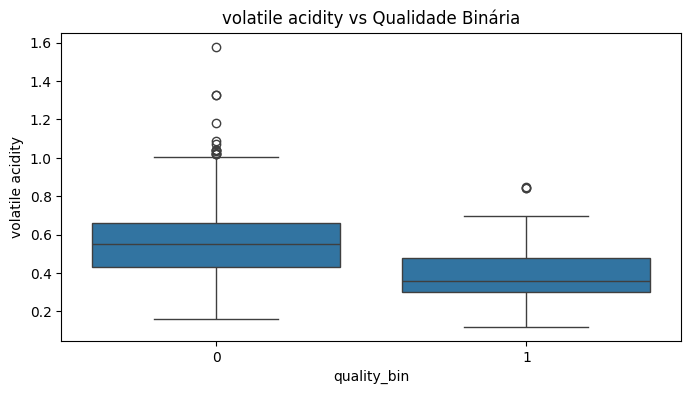

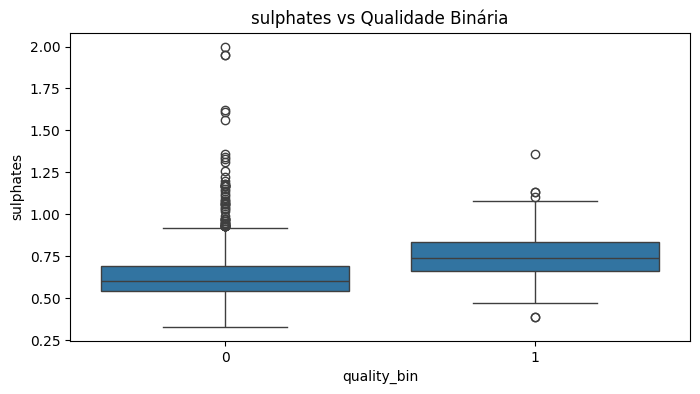

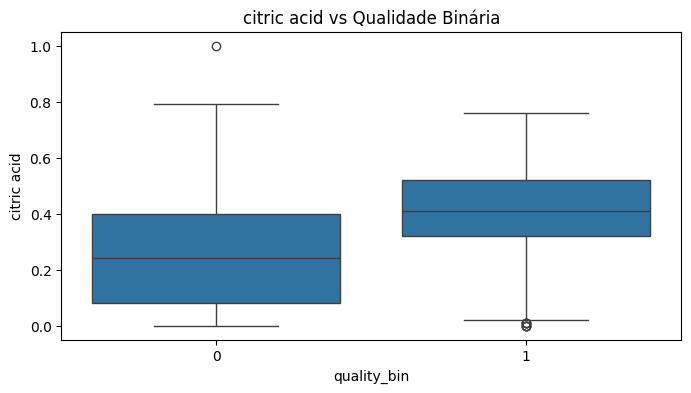

In [ ]:
features = ['alcohol','volatile acidity','sulphates','citric acid']

for col in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='quality_bin', y=col)
    plt.title(f'{col} vs Qualidade Binária')
    plt.show()


## Criação de modelos de Treinos e testes
Separar treino e teste

In [ ]:
X = df.drop(['quality','quality_bin','Id'], axis=1)
y = df['quality_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalização

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modelos

In [ ]:
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
print('Logistic Regression')
print(classification_report(y_test, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229



# Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest')
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.67      0.57      0.62        28

    accuracy                           0.91       229
   macro avg       0.80      0.77      0.78       229
weighted avg       0.91      0.91      0.91       229



# SVM

In [ ]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM')
print(classification_report(y_test, y_pred_svm))


SVM
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.62      0.29      0.39        28

    accuracy                           0.89       229
   macro avg       0.76      0.63      0.67       229
weighted avg       0.87      0.89      0.87       229



# Matriz de Confusão

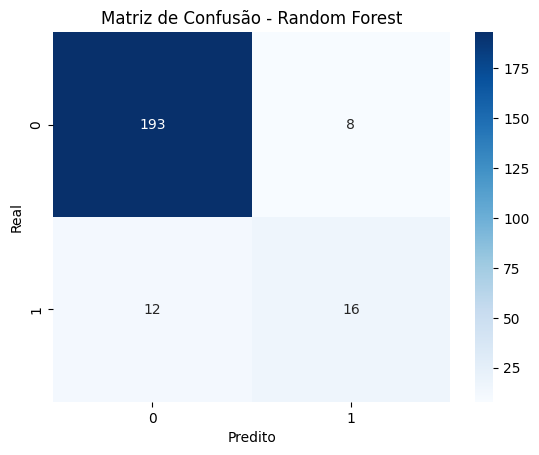

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


# Importância das variáveis (Random Forest)

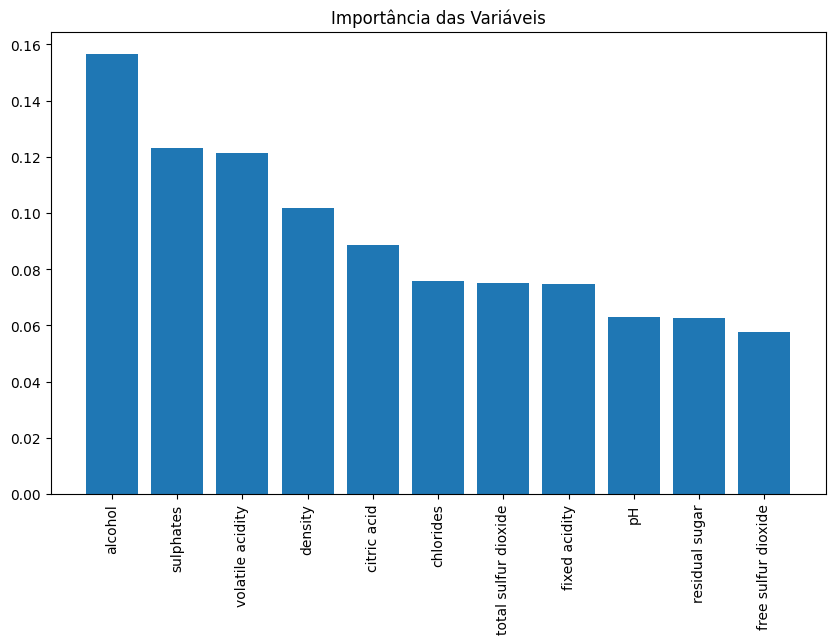

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title('Importância das Variáveis')
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()


# ROC-AUC

In [ ]:
rf_probs = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, rf_probs)
print('ROC-AUC (Random Forest):', auc)


ROC-AUC (Random Forest): 0.958955223880597


# Modelos Avançados — XGBoost e LightGBM

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


#XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))



XGBoost
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       201
           1       0.72      0.64      0.68        28

    accuracy                           0.93       229
   macro avg       0.84      0.80      0.82       229
weighted avg       0.92      0.93      0.92       229



#LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM")
print(classification_report(y_test, y_pred_lgbm))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 131, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143326 -> initscore=-1.787935
[LightGBM] [Info] Start training from score -1.787935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       201
           1   

# Interpretabilidade — SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


# SHAP Summary Plot

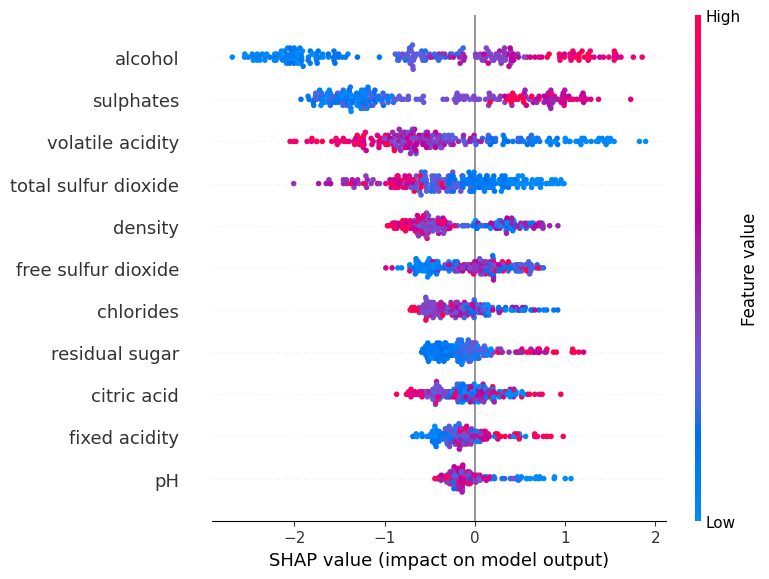

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# SHAP Force Plot

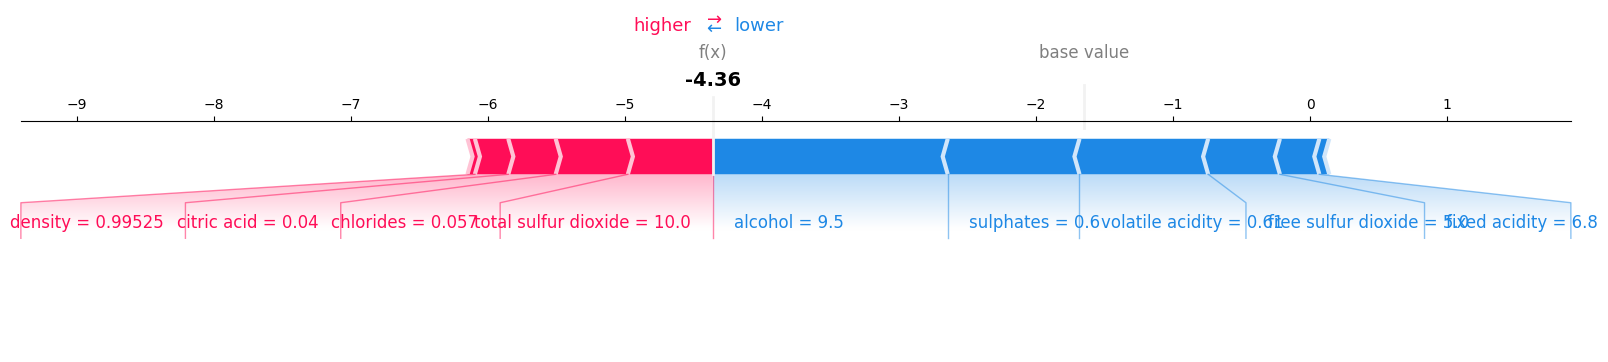

In [ ]:
idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx, :],
    matplotlib=True)
